In [1]:
import os 
# Load Python's operating-system tools so I can inspect files.

In [2]:
os.listdir()
# Show me the files and folders in the location where Python is currently working.

['.ipynb_checkpoints',
 'HealthConnect Pre-EDA Stage Summary.docx',
 'HealthConnect_Appointment_Data.csv',
 'HealthConnect_clean.csv',
 'Loading Data.ipynb']

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("HealthConnect_Appointment_Data.csv")

## DATA PREPARATION

In [4]:
df.head()


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [5]:
df.shape
# Tell me the dimensions of the HealthConnect dataset.(number of rows, number of columns)

(5000, 18)

In [6]:
df.columns
# Returns the names of all columns in the dataset.

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

In [8]:
df.isnull().sum()
# For every column in the HealthConnect dataset, count how many values are missing.

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [9]:
df.duplicated().sum()
# Count the number of completely duplicated appointment records in the HealthConnect dataset.

np.int64(0)

In [10]:
df["appointment_id"].duplicated().sum()
# Count how many appointment IDs are duplicated in the HealthConnect dataset

np.int64(0)

In [11]:
df["patient_id"].nunique()
# Count the number of unique patients represented in the 5,000 appointment records.

1696

In [12]:
df.shape[0] / df["patient_id"].nunique()
# On average, how many appointment records are represented per patient?

2.94811320754717

In [13]:
(df["previous_no_shows"] > df["previous_appointments"]).sum()
# Count the number of appointments where previous no-shows exceed previous appointments.

np.int64(0)

In [14]:
numeric_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

(df[numeric_columns] < 0).sum()

age                      0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
distance_to_clinic_km    0
waiting_time_minutes     0
dtype: int64

In [15]:
df["appointment_outcome"].value_counts()
# This will tell us:

# Which outcome categories exist.
# Whether unexpected categories are present.
# How many records belong to each category.

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [16]:
df["appointment_type"].value_counts()

appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

In [17]:
df["appointment_time"].value_counts()

appointment_time
Morning      2227
Afternoon    2094
Evening       679
Name: count, dtype: int64

In [18]:
df["appointment_day"].value_counts().sort_values()

appointment_day
Thursday     684
Tuesday      689
Monday       701
Saturday     724
Friday       728
Sunday       737
Wednesday    737
Name: count, dtype: int64

In [19]:
df["gender"].value_counts()

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

In [20]:
df["reminder_sent"].value_counts()

reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

In [21]:
pd.crosstab(df["reminder_sent"], df["reminder_channel"], dropna=False)
# A pandas function that creates a cross-tabulation, allowing us to compare two categorical variables. reminder_sent against reminder_channel

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


In [22]:
df["age_group"].value_counts()

age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

In [23]:
expected_age_group = pd.cut(
    df["age"],
    bins=[17, 24, 34, 44, 54, 64, float("inf")],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

(expected_age_group != df["age_group"]).sum()
# How many records have an age_group that doesn't match the patient's actual age?

np.int64(0)

In [24]:
df[["booking_date", "appointment_date"]].head()

,booking_date,appointment_date
0,2/6/2025,2/18/2025
1,2/25/2026,2/27/2026
2,11/16/2025,12/24/2025
3,7/18/2025,8/28/2025
4,7/9/2025,8/25/2025


In [25]:
df["booking_date"] = pd.to_datetime(df["booking_date"], format="%m/%d/%Y")
df["appointment_date"] = pd.to_datetime(df["appointment_date"], format="%m/%d/%Y")
# booking_date and appointment_date were successfully converted from string values to datetime format using the dataset's month/day/year format.

In [26]:
df[["booking_date", "appointment_date"]].head()

,booking_date,appointment_date
0,2025-02-06,2025-02-18
1,2026-02-25,2026-02-27
2,2025-11-16,2025-12-24
3,2025-07-18,2025-08-28
4,2025-07-09,2025-08-25


In [27]:
df[["booking_date", "appointment_date"]].dtypes

# Both date columns are now recognised as proper datetime variables.

booking_date        datetime64[us]
appointment_date    datetime64[us]
dtype: object

In [28]:
(df["appointment_date"] < df["booking_date"]).sum()
# Count how many appointments have an appointment date earlier than their booking date.

np.int64(0)

In [29]:
calculated_lead_days = (
    df["appointment_date"] - df["booking_date"]
).dt.days

(calculated_lead_days != df["booking_lead_days"]).sum()

np.int64(0)

In [30]:
calculated_day = df["appointment_date"].dt.day_name()

(calculated_day != df["appointment_day"]).sum()

np.int64(0)

In [31]:
df["distance_to_clinic_km"].describe()

count    4910.000000
mean       10.109572
std         6.590030
min         0.500000
25%         5.300000
50%         8.700000
75%        13.500000
max        45.000000
Name: distance_to_clinic_km, dtype: float64

In [32]:
df["waiting_time_minutes"].describe()

count    4940.000000
mean       24.189676
std        10.863184
min         2.000000
25%        17.000000
50%        24.000000
75%        32.000000
max        68.000000
Name: waiting_time_minutes, dtype: float64

In [33]:
df[df["distance_to_clinic_km"].isna()]["appointment_outcome"].value_counts()
# identifies records where distance is missing then selects the outcome for those records. Finally counts the outcomes

appointment_outcome
No-Show      47
Attended     39
Cancelled     4
Name: count, dtype: int64

In [34]:
df[df["waiting_time_minutes"].isna()]["appointment_outcome"].value_counts()
# # identifies records where waiting_time is missing then selects the outcome for those records. Finally counts the outcomes

appointment_outcome
No-Show      37
Attended     21
Cancelled     2
Name: count, dtype: int64

In [35]:
df.isna().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [36]:
df_clean = df.copy()

In [37]:
df_clean.shape

(5000, 18)

In [38]:
df_clean.to_csv("HealthConnect_clean.csv", index=False)

In [39]:
import os

os.path.exists("HealthConnect_clean.csv")

True

# Exploratory Data Analysis (EDA)

In [40]:
df_clean["appointment_outcome"].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [41]:
df_clean["appointment_outcome"].value_counts(normalize=True).mul(100).round(2)

appointment_outcome
No-Show      48.46
Attended     46.28
Cancelled     5.26
Name: proportion, dtype: float64

In [42]:
id="8h0m2q"
no_show_rate = (
    (df_clean["appointment_outcome"] == "No-Show").mean() * 100
)

no_show_rate

np.float64(48.46)

### Overall Appointment Outcomes

#### From the 5,000 appointments:

##### 2,423 (48.46%) were No-Shows.
##### 2,314 (46.28%) were Attended.
##### 263 (5.26%) were Cancelled.
#### Interpretation

##### The most important initial finding is that No-Shows represent the largest appointment outcome category, accounting for almost half of all scheduled appointments.

In [43]:
pd.crosstab(
    df_clean["appointment_type"],
    df_clean["appointment_outcome"]
)

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,272,26,295
Follow-up,616,77,728
General Consultation,1007,106,973
Specialist Consultation,419,54,427


## What can we see already?

##### The raw No-Show counts are highest for:

##### General Consultation — 973
##### Follow-up — 728
##### Specialist Consultation — 427
##### Diagnostic Test — 295

##### However, we cannot conclude that General Consultation has the highest No-Show problem yet.

##### Why?

##### Because General Consultation also has the largest number of appointments overall.

##### For example:

##### General Consultation has 2,086 appointments
##### Diagnostic Test has only 593 appointments

##### Naturally, the category with more appointments will tend to have more No-Shows.

##### So instead of comparing No-Show counts, we need to compare the No-Show rate within each appointment type.

In [44]:
no_show_by_type = (
    df_clean.groupby("appointment_type")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_type

appointment_type
Diagnostic Test            49.75
Follow-up                  51.23
General Consultation       46.64
Specialist Consultation    47.44
Name: appointment_outcome, dtype: float64

#### Appointment type showed moderate variation in No-Show rates. Follow-up appointments had the highest No-Show rate at 51.23%, followed by Diagnostic Tests at 49.75%. Specialist Consultations recorded 47.44%, while General Consultations had the lowest rate at 46.64%. Compared with the overall No-Show rate of 48.46%, the differences were relatively small, suggesting that appointment type alone may not be a strong determinant of appointment non-attendance.

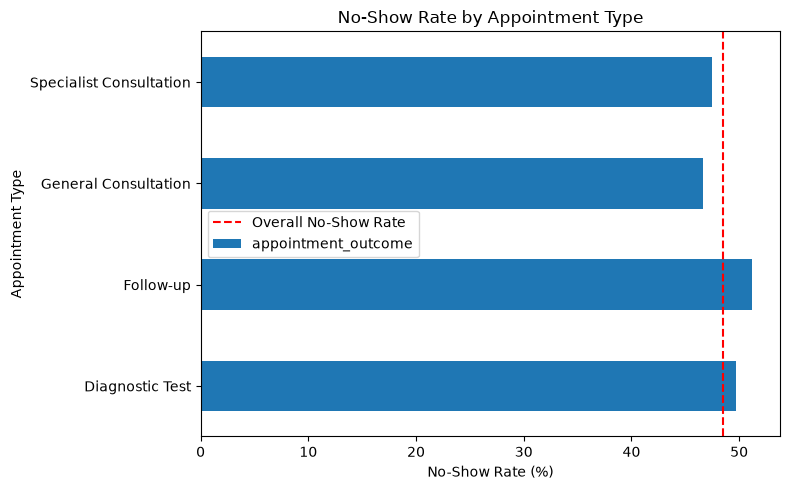

In [45]:
plt.figure(figsize=(8, 5))

no_show_by_type.plot(kind="barh")

plt.axvline(
    x=no_show_rate,
    color='red',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Appointment Type")
plt.ylabel("Appointment Type")
plt.xlabel("No-Show Rate (%)")
plt.xticks()
plt.legend()
plt.tight_layout()

plt.show()

##### The No-Show rates were:

##### Follow-up: 51.23%
##### Diagnostic Test: 49.75%
##### Specialist Consultation: 47.44%
##### General Consultation: 46.64%

##### Compared with the 48.46% overall baseline, Follow-up and Diagnostic Test appointments were above average, while Specialist Consultation and General Consultation were below average.

##### The differences are relatively small, so appointment type does not appear to be a particularly strong differentiator on its own. We'll need to examine other factors before drawing conclusions.

## Outcome Counts by Age Group

In [46]:
pd.crosstab(
    df_clean["age_group"],
    df_clean["appointment_outcome"]
)

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,257,24,283
25-34,353,33,397
35-44,374,49,396
45-54,365,47,381
55-64,360,34,406
65+,605,76,560


In [47]:
no_show_by_age = (
    df_clean.groupby("age_group")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_age

age_group
18-24    50.18
25-34    50.70
35-44    48.35
45-54    48.05
55-64    50.75
65+      45.12
Name: appointment_outcome, dtype: float64

##### No-Show rates varied across age groups. The 65+ group recorded the lowest No-Show rate at 45.12%, while the 55–64 group recorded the highest at 50.75%. Younger groups such as 18–24 and 25–34 also had rates above the overall 48.46% baseline. Overall, age group shows some variation in appointment attendance, with the most notable difference being the lower No-Show rate among patients aged 65 and above.

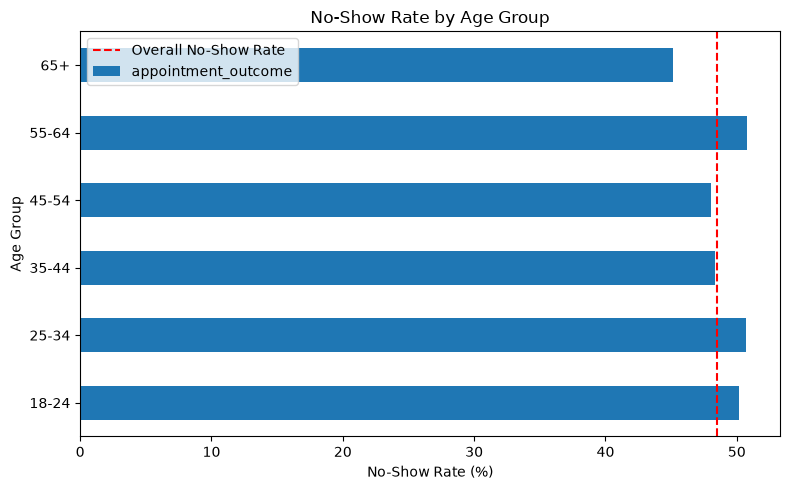

In [48]:
plt.figure(figsize=(8, 5))
no_show_by_age.plot(kind="barh")

plt.axvline(
    x=no_show_rate,
    color='red',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Age Group")
plt.ylabel("Age Group")
plt.xlabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Gender

In [49]:
pd.crosstab(
    df_clean["gender"],
    df_clean["appointment_outcome"]
)

appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,1153,130,1205
Male,1103,130,1171
Prefer not to say,58,3,47


In [50]:
no_show_by_gender = (
    df_clean.groupby("gender")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_gender

gender
Female               48.43
Male                 48.71
Prefer not to say    43.52
Name: appointment_outcome, dtype: float64

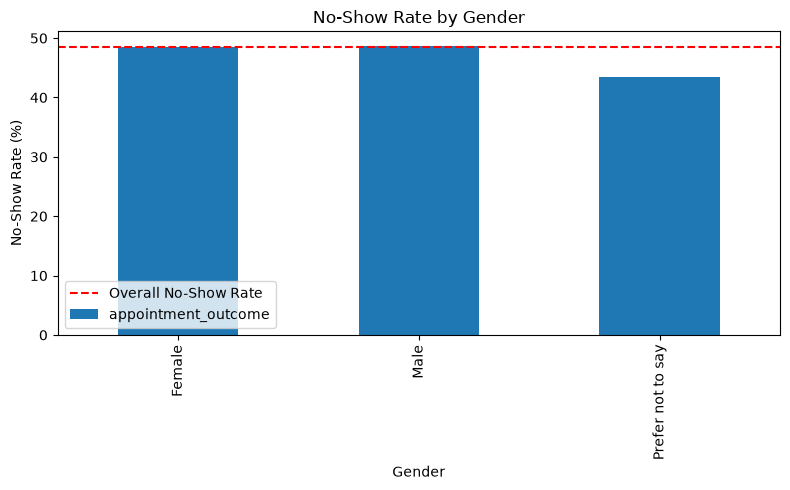

In [59]:
plt.figure(figsize=(8, 5))
no_show_by_gender.plot(kind="bar")
plt.axhline(
    y=no_show_rate,
    color='red',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Appointment Day

In [60]:
pd.crosstab(
    df_clean["appointment_day"],
    df_clean["appointment_outcome"]
)

appointment_outcome,Attended,Cancelled,No-Show
appointment_day,,,
Friday,357,32,339
Monday,307,46,348
Saturday,344,41,339
Sunday,332,33,372
Thursday,309,40,335
Tuesday,338,27,324
Wednesday,327,44,366


In [61]:
no_show_by_day = (
    df_clean.groupby("appointment_day")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_day

appointment_day
Friday       46.57
Monday       49.64
Saturday     46.82
Sunday       50.47
Thursday     48.98
Tuesday      47.02
Wednesday    49.66
Name: appointment_outcome, dtype: float64

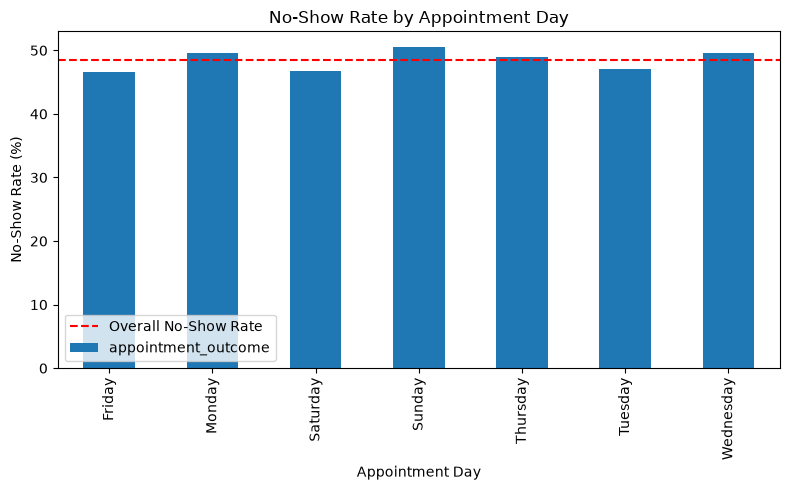

In [62]:
plt.figure(figsize=(8, 5))

no_show_by_day.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    color='r',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Appointment Day")
plt.xlabel("Appointment Day")
plt.ylabel("No-Show Rate (%)")

plt.legend()

plt.tight_layout()
plt.show()

In [63]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

no_show_by_day = no_show_by_day.reindex(day_order)

no_show_by_day

appointment_day
Monday       49.64
Tuesday      47.02
Wednesday    49.66
Thursday     48.98
Friday       46.57
Saturday     46.82
Sunday       50.47
Name: appointment_outcome, dtype: float64

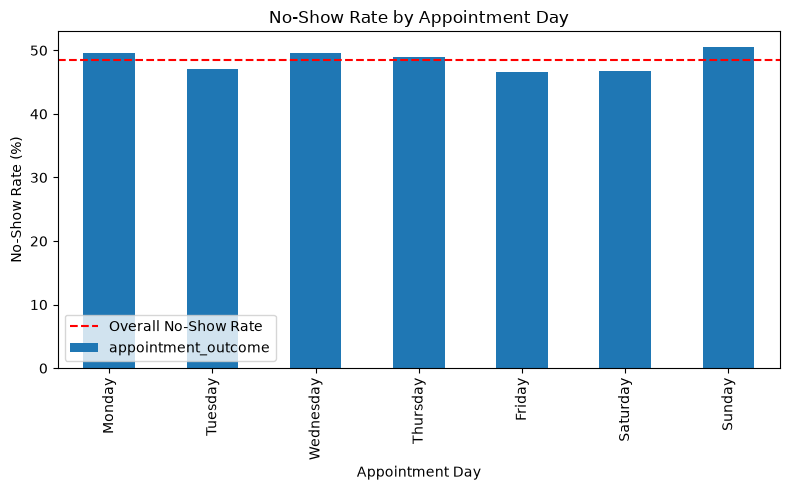

In [65]:
plt.figure(figsize=(8, 5))

no_show_by_day.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    color='r',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Appointment Day")
plt.xlabel("Appointment Day")
plt.ylabel("No-Show Rate (%)")

plt.legend()

plt.tight_layout()
plt.show()

# Appointment Time

In [66]:
no_show_by_time = (
    df_clean.groupby("appointment_time")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_time

appointment_time
Afternoon    48.38
Evening      49.78
Morning      48.14
Name: appointment_outcome, dtype: float64

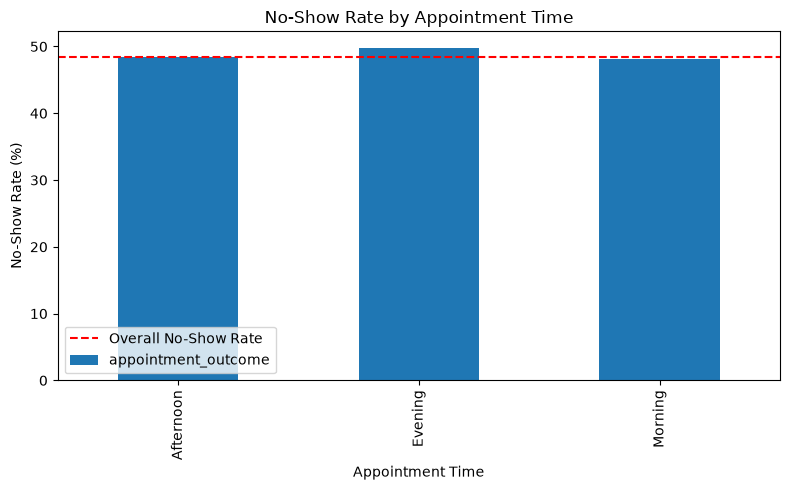

In [68]:
plt.figure(figsize=(8, 5))

no_show_by_time.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    color='r',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Appointment Time")
plt.xlabel("Appointment Time")
plt.ylabel("No-Show Rate (%)")

plt.legend()

plt.tight_layout()
plt.show()

# booking_lead_days

In [69]:
df_clean["booking_lead_days"].describe()

count    5000.00000
mean       29.63860
std        17.39936
min         0.00000
25%        15.00000
50%        30.00000
75%        45.00000
max        60.00000
Name: booking_lead_days, dtype: float64

In [70]:
lead_time_bins = [0, 14, 29, 44, 60]

lead_time_labels = [
    "0-14 days",
    "15-29 days",
    "30-44 days",
    "45-60 days"
]

df_clean["lead_time_group"] = pd.cut(
    df_clean["booking_lead_days"],
    bins=lead_time_bins,
    labels=lead_time_labels,
    include_lowest=True
)

In [71]:
df_clean["lead_time_group"].value_counts().sort_index()

lead_time_group
0-14 days     1242
15-29 days    1250
30-44 days    1257
45-60 days    1251
Name: count, dtype: int64

In [72]:
no_show_by_lead_time = (
    df_clean.groupby("lead_time_group", observed=True)["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_lead_time

lead_time_group
0-14 days     30.60
15-29 days    43.04
30-44 days    52.82
45-60 days    67.23
Name: appointment_outcome, dtype: float64

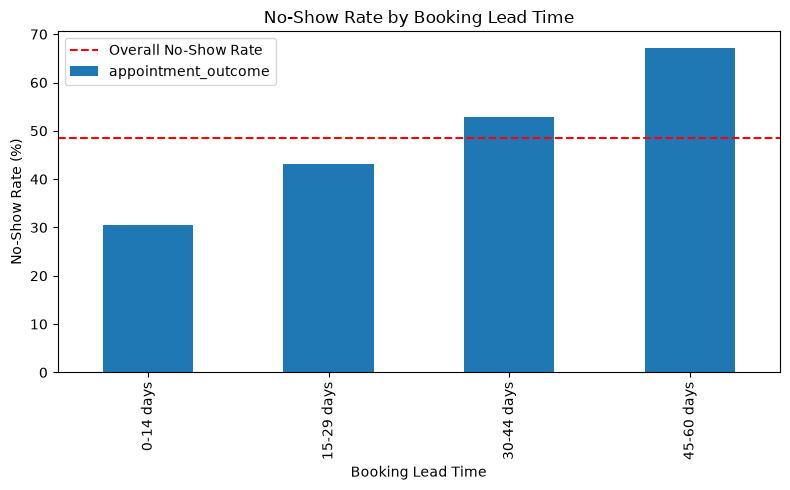

In [73]:
plt.figure(figsize=(8, 5))

no_show_by_lead_time.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    color='r',
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

##### HealthConnect should pay particular attention to appointments booked 30+ days in advance, and especially those booked 45–60 days ahead.

##### These appointments could be placed into a high-risk reminder group, with stronger follow-up closer to the appointment date.

# previous_appointments

In [74]:
df_clean["previous_appointments"].describe()

count    5000.000000
mean        3.013800
std         1.741211
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        11.000000
Name: previous_appointments, dtype: float64

In [75]:
previous_appointment_bins = [-1, 0, 2, 4, float("inf")]

previous_appointment_labels = [
    "0 appointments",
    "1-2 appointments",
    "3-4 appointments",
    "5+ appointments"
]

df_clean["previous_appointment_group"] = pd.cut(
    df_clean["previous_appointments"],
    bins=previous_appointment_bins,
    labels=previous_appointment_labels
)

In [76]:
df_clean["previous_appointment_group"].value_counts().sort_index()

previous_appointment_group
0 appointments       242
1-2 appointments    1880
3-4 appointments    1947
5+ appointments      931
Name: count, dtype: int64

In [77]:
no_show_by_previous = (
    df_clean.groupby(
        "previous_appointment_group",
        observed=True
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_previous

previous_appointment_group
0 appointments      42.98
1-2 appointments    46.22
3-4 appointments    49.77
5+ appointments     51.66
Name: appointment_outcome, dtype: float64

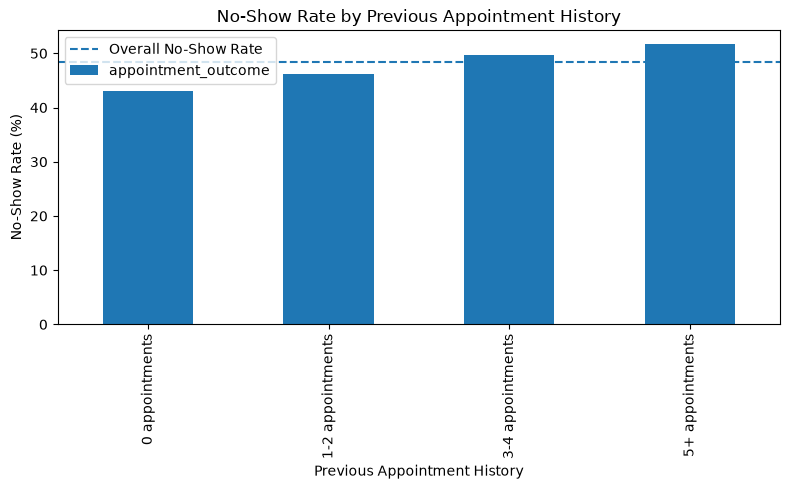

In [78]:
plt.figure(figsize=(8, 5))

no_show_by_previous.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Previous Appointment History")
plt.xlabel("Previous Appointment History")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

##### Patients with a longer appointment history may warrant additional monitoring, particularly those with 5+ previous appointments, where the observed No-Show rate reaches 51.66%.



# reminder_sent

In [79]:
no_show_by_reminder = (
    df_clean.groupby("reminder_sent")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_reminder

reminder_sent
No     51.39
Yes    47.36
Name: appointment_outcome, dtype: float64

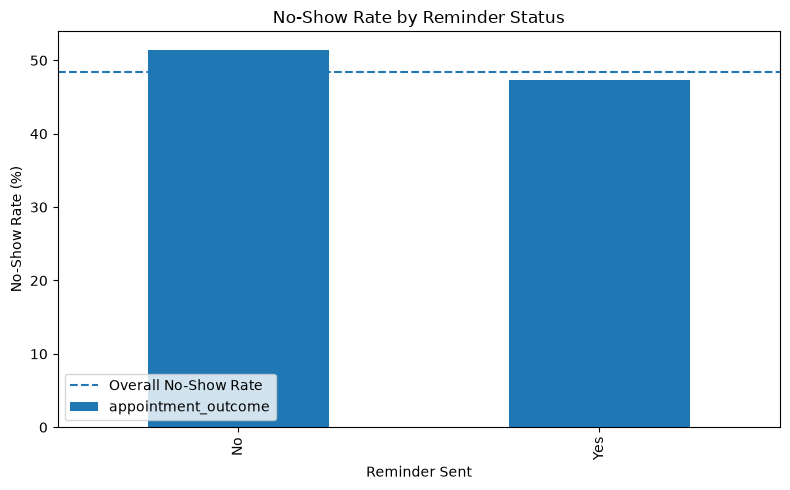

In [80]:
plt.figure(figsize=(8, 5))

no_show_by_reminder.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Reminder Status")
plt.xlabel("Reminder Sent")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

#### Appointments with reminders had a lower observed No-Show rate. This suggests that HealthConnect's reminder process is potentially valuable and should be maintained or strengthened.

# no_show_by_channel

In [81]:
no_show_by_channel = (
    df_clean[df_clean["reminder_sent"] == "Yes"]
    .groupby("reminder_channel")["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_channel

reminder_channel
Email       48.41
SMS         45.75
WhatsApp    49.77
Name: appointment_outcome, dtype: float64

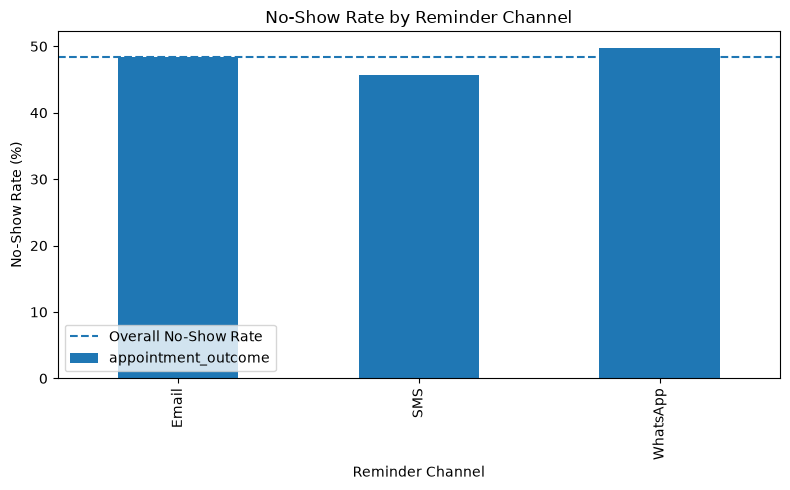

In [82]:
plt.figure(figsize=(8, 5))

no_show_by_channel.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Reminder Channel")
plt.xlabel("Reminder Channel")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

# distance_to_clinic_km

In [83]:
df_clean["distance_to_clinic_km"].describe()

count    4910.000000
mean       10.109572
std         6.590030
min         0.500000
25%         5.300000
50%         8.700000
75%        13.500000
max        45.000000
Name: distance_to_clinic_km, dtype: float64

In [84]:
distance_bins = [0, 5, 10, 15, float("inf")]

distance_labels = [
    "0-5 km",
    "5-10 km",
    "10-15 km",
    "15+ km"
]

df_clean["distance_group"] = pd.cut(
    df_clean["distance_to_clinic_km"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

In [85]:
df_clean["distance_group"].value_counts().sort_index()

distance_group
0-5 km      1156
5-10 km     1692
10-15 km    1132
15+ km       930
Name: count, dtype: int64

In [86]:
no_show_by_distance = (
    df_clean.groupby(
        "distance_group",
        observed=True
    )["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_distance

distance_group
0-5 km      46.45
5-10 km     46.51
10-15 km    48.50
15+ km      54.09
Name: appointment_outcome, dtype: float64

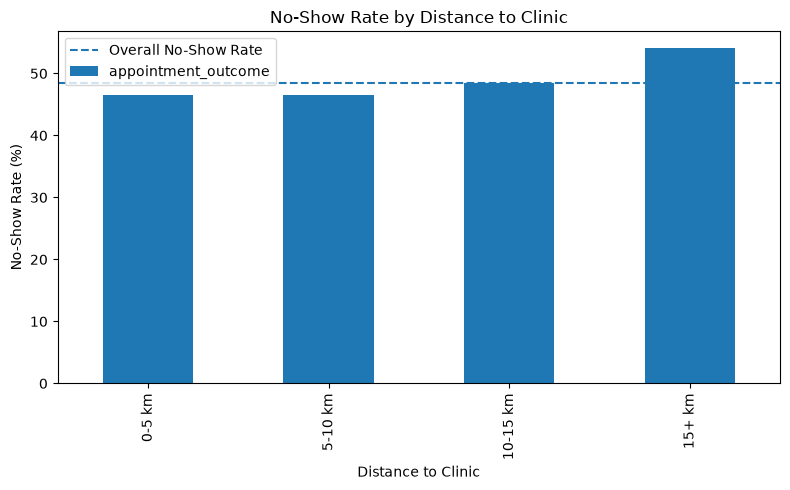

In [87]:
plt.figure(figsize=(8, 5))

no_show_by_distance.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Distance to Clinic")
plt.xlabel("Distance to Clinic")
plt.ylabel("No-Show Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

### No-Show Rates remain around 46–49% for patients within 15 km, but increase to 54.09% for patients living 15+ km away.

In [88]:
df_clean["waiting_time_minutes"].describe()

count    4940.000000
mean       24.189676
std        10.863184
min         2.000000
25%        17.000000
50%        24.000000
75%        32.000000
max        68.000000
Name: waiting_time_minutes, dtype: float64

In [89]:
waiting_time_bins = [0, 15, 30, 45, float("inf")]

waiting_time_labels = [
    "0-15 min",
    "16-30 min",
    "31-45 min",
    "46+ min"
]

df_clean["waiting_time_group"] = pd.cut(
    df_clean["waiting_time_minutes"],
    bins=waiting_time_bins,
    labels=waiting_time_labels,
    include_lowest=True
)

In [90]:
no_show_by_waiting_time = (
    df_clean.groupby("waiting_time_group", observed=True)["appointment_outcome"]
    .apply(lambda x: (x == "No-Show").mean() * 100)
    .round(2)
)

no_show_by_waiting_time

waiting_time_group
0-15 min     47.06
16-30 min    49.19
31-45 min    47.78
46+ min      46.67
Name: appointment_outcome, dtype: float64

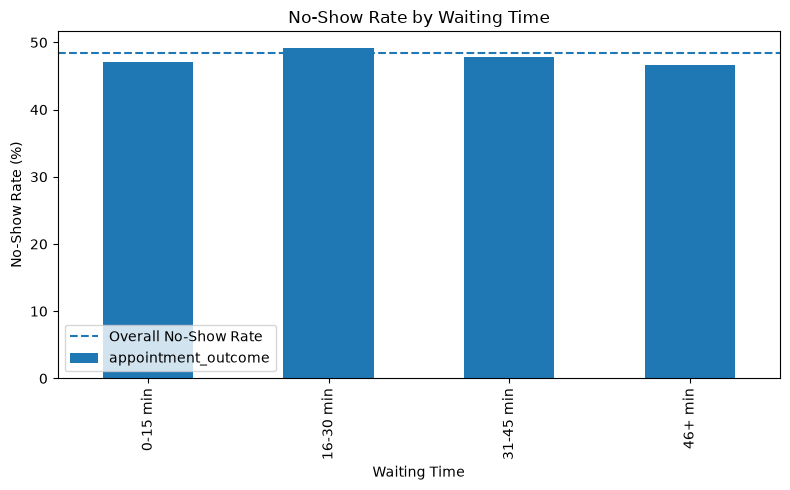

In [91]:
plt.figure(figsize=(8, 5))

no_show_by_waiting_time.plot(kind="bar")

plt.axhline(
    y=no_show_rate,
    linestyle="--",
    label="Overall No-Show Rate"
)

plt.title("No-Show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-Show Rate (%)")

plt.legend()
plt.tight_layout()
plt.show()